# Lucky Cement: forecasting intelligence and decision story

Prepared for MGT-353 | Syed Zafar Naveed | 5 October 2026

Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Lucky Cement's disclosed scale, not actual company records.

Run cells in order. Keep the dataset CSV in the same directory. Existing CSV values are reused and never regenerated to improve accuracy. Packages: numpy, pandas, scipy, matplotlib. In Google Colab, upload the Dataset.csv into the session first; run from that directory. No private company records are used.

The forthcoming plan is provisional because the holdout Tracking Signal is outside the assumed control band. The recommendation concerns an illustrative territory, not Lucky Cement company-wide production.

## 1. Setup and decision

In [1]:
from pathlib import Path
import json, math, hashlib, io, contextlib, base64, csv
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

ROOT = Path.cwd()
PREFIX = 'MGT353_Forecasting_M1_SyedZafarNaveed_LuckyCement'
LABEL = "Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Lucky Cement's disclosed scale, not actual company records."
DECISION = 'How many tonnes of Ordinary Portland Cement should Lucky Cement plan to supply to an illustrative Karachi/Sindh dealer territory over the next 12 weeks, and how much dispatch-linked production should it commit now versus keep flexible?'
SEED = 3532026
REVENUE = 136527017000
plt.rcParams.update({'figure.dpi':140,'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.alpha':.16,'font.size':10})
print(LABEL)
print(DECISION)
print('Owner: territory demand planner, with production and dispatch managers. Units: tonnes; 20 assumed 50-kg bags per tonne.')



Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Lucky Cement's disclosed scale, not actual company records.
How many tonnes of Ordinary Portland Cement should Lucky Cement plan to supply to an illustrative Karachi/Sindh dealer territory over the next 12 weeks, and how much dispatch-linked production should it commit now versus keep flexible?
Owner: territory demand planner, with production and dispatch managers. Units: tonnes; 20 assumed 50-kg bags per tonne.


## 2. Reproducible synthetic data; do not regenerate to improve accuracy

In [2]:
data_path = ROOT / (PREFIX + '_Dataset.csv')
if data_path.exists():
    df = pd.read_csv(data_path, parse_dates=['Week_Start_Date'])
else:
    rng = np.random.default_rng(SEED)
    dates = pd.date_range(end='2026-09-28', periods=156, freq='W-MON')
    t = np.arange(156)
    month = dates.month.to_numpy()
    event = np.isin(month,[3,4,5,6]).astype(int)
    monsoon = np.isin(month,[7,8,9]).astype(int)
    # Months and blocks represent broad construction seasonality, not verified company events.
    price = 20000 + (t>=35)*1100 + (t>=79)*900 + (t>=123)*800
    promo = np.zeros(156,dtype=int)
    promo[rng.choice(156,34,replace=False)] = 1
    depth = promo*rng.choice([2.,3.,4.,5.],156)
    index = 100 + .035*t + 4*np.sin(2*np.pi*t/52) + rng.normal(0,4.5,156)
    stockout = np.zeros(156,dtype=int)
    stockout[[22,23,68,116,149]] = 1
    exceptional = np.array(['']*156, dtype=object)
    shock = np.zeros(156)
    for indices,text,effect in [([22,23],'Transport disruption / stockout',-80),([61,62],'Competitor dealer discount',-280),([105],'One-off construction order',500),([149],'Unexpected dispatch interruption / stockout',-60)]:
        exceptional[indices] = text
        shock[indices] = effect
    baseline = 1550 + 1.2*t - .035*(price-20000) + 13*(index-100) + 240*event - 260*monsoon
    uplift = promo*(.10 + depth*.025 + rng.uniform(-.015,.035,156))
    availability_loss = stockout*rng.uniform(.24,.38,156)
    y = np.maximum(250,np.rint(baseline*(1+uplift)*(1-availability_loss)+shock+rng.normal(0,105,156)))
    # Prior forecast uses lagged observations only plus independent forecast noise.
    prior = []
    for i in range(156):
        history = y[max(0,i-4):i]
        prior.append(round((history.mean() if len(history) else 1550)*1.02+rng.normal(0,60)))
    df = pd.DataFrame({'Week_Start_Date':dates,'Product_or_Category':'Ordinary Portland Cement','Location_or_Channel':'Illustrative Karachi/Sindh dealer territory','Actual_Demand_Tonnes':y.astype(int),'Historical_Forecast_Tonnes':prior,'Price_PKR_per_Tonne':price,'Promo_Flag':promo,'Promo_Depth':depth,'Event_Flag':event,'Construction_Activity_Index':index.round(2),'Monsoon_Flag':monsoon,'Stockout_Flag':stockout,'Exceptional_Event':exceptional})
    df.to_csv(data_path,index=False)
if 'Dataset_Disclosure' not in df.columns:
    df.insert(0,'Dataset_Disclosure',LABEL)
    df.to_csv(data_path,index=False)
assert len(df)==156 and df.Week_Start_Date.is_monotonic_increasing
assert df.Week_Start_Date.diff().dropna().eq(pd.Timedelta(days=7)).all()
assert not df.Week_Start_Date.duplicated().any() and (df.Actual_Demand_Tonnes>0).all()
assert df.Price_PKR_per_Tonne.nunique()>1 and .15<=df.Promo_Flag.mean()<=.30
assert pd.crosstab(df.Event_Flag,df.Promo_Flag).shape==(2,2)
DATA_HASH = hashlib.sha256(data_path.read_bytes()).hexdigest()
train_df, test_df = df.iloc[:-12].copy(), df.iloc[-12:].copy()
y = df.Actual_Demand_Tonnes.to_numpy(dtype=float)
tr = train_df.Actual_Demand_Tonnes.to_numpy(dtype=float)
actual = test_df.Actual_Demand_Tonnes.to_numpy(dtype=float)
print(f'Dataset frozen: {DATA_HASH}')
print(f'Train: {train_df.Week_Start_Date.min().date()} to {train_df.Week_Start_Date.max().date()} (144 weeks)')
print(f'Holdout: {test_df.Week_Start_Date.min().date()} to {test_df.Week_Start_Date.max().date()} (12 weeks)')
print(f'Promotion share: {df.Promo_Flag.mean():.1%}; price levels: {df.Price_PKR_per_Tonne.nunique()}')
fy26 = df[(df.Week_Start_Date>='2025-07-01') & (df.Week_Start_Date<='2026-06-30')]
territory_sales = float((fy26.Actual_Demand_Tonnes*fy26.Price_PKR_per_Tonne*(1-fy26.Promo_Depth/100)).sum())
print(f'Illustrative FY26 territory sales proxy: PKR {territory_sales/1e9:.3f}bn, {territory_sales/REVENUE:.2%} of standalone net revenue. Scale check only; not a disclosed market share.')



Dataset frozen: a12f06c4579e96303885bb629bb9717b8e7fe90112580a31950d89a132171269
Train: 2023-10-09 to 2026-07-06 (144 weeks)
Holdout: 2026-07-13 to 2026-09-28 (12 weeks)
Promotion share: 21.8%; price levels: 4
Illustrative FY26 territory sales proxy: PKR 2.021bn, 1.48% of standalone net revenue. Scale check only; not a disclosed market share.


## 3. Demand statistics and diagnosis

           Full_history  Training_only
Mean            1697.37        1724.46
Median          1700.00        1743.50
Sample_SD        322.22         318.22
Minimum         1041.00        1117.00
Maximum         2485.00        2485.00
Range           1444.00        1368.00
CV_pct            18.98          18.45
The illustrative cement series combines a modest underlying growth trend with higher construction-season demand and a weaker monsoon block. Price changes occur in steps rather than every week. Dealer incentives create irregular dispatch lifts, while construction activity varies independently and contributes additional movement. Four exceptional incidents interrupt the normal pattern, including two availability-constrained episodes; these must not be interpreted as proof that customer demand disappeared. A simple level forecast may miss seasonal transitions, while a short moving average can be pulled down by recent stockouts. Seasonal naive forecasting provides a transparent bench

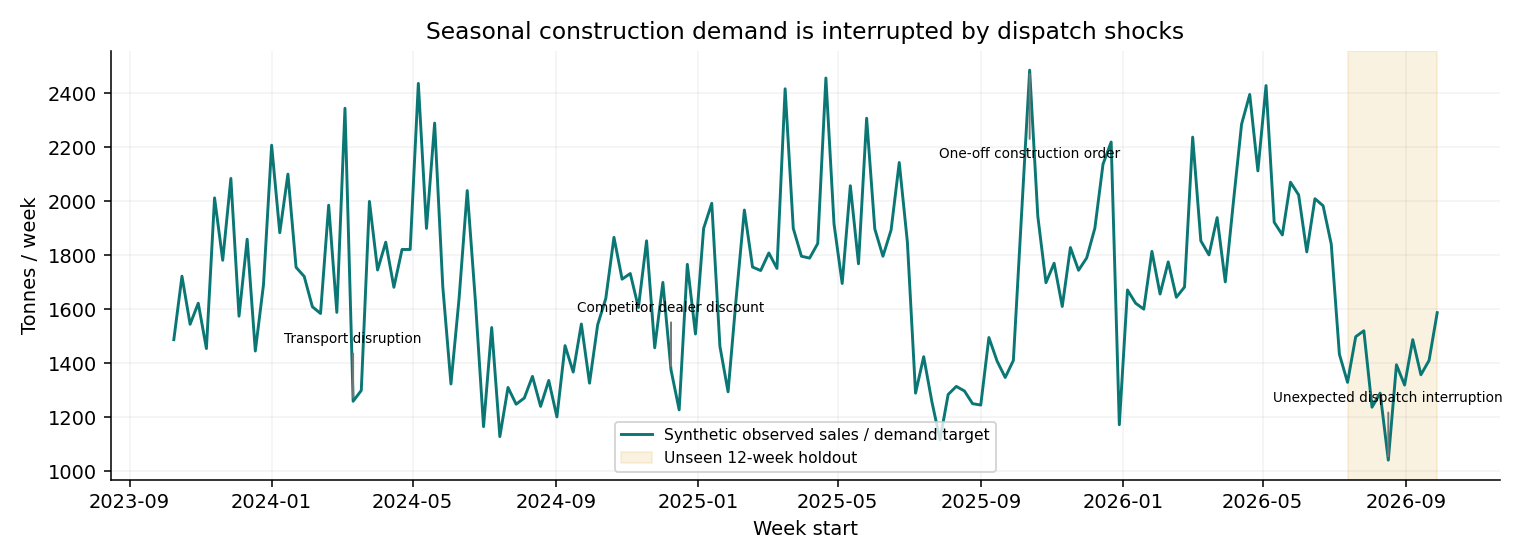

In [3]:
def descriptive(v):
    return {'Mean':float(np.mean(v)),'Median':float(np.median(v)),'Sample_SD':float(np.std(v,ddof=1)),'Minimum':float(np.min(v)),'Maximum':float(np.max(v)),'Range':float(np.ptp(v)),'CV_pct':float(np.std(v,ddof=1)/np.mean(v)*100)}
desc = pd.DataFrame({'Full_history':descriptive(y),'Training_only':descriptive(tr)})
desc.to_csv(ROOT/(PREFIX+'_Descriptive_Statistics.csv'))
print(desc.round(2).to_string())
DIAGNOSIS = 'The illustrative cement series combines a modest underlying growth trend with higher construction-season demand and a weaker monsoon block. Price changes occur in steps rather than every week. Dealer incentives create irregular dispatch lifts, while construction activity varies independently and contributes additional movement. Four exceptional incidents interrupt the normal pattern, including two availability-constrained episodes; these must not be interpreted as proof that customer demand disappeared. A simple level forecast may miss seasonal transitions, while a short moving average can be pulled down by recent stockouts. Seasonal naive forecasting provides a transparent benchmark but repeats last year’s unusual weeks. A calendar seasonal-trend model can recognise month effects and gradual change, although it cannot anticipate unannounced disruptions. Model parameters and diagnosis for selection use training observations only; the full-history chart is descriptive, not permission to tune on holdout outcomes.'
print(DIAGNOSIS)
fig,ax=plt.subplots(figsize=(11,4))
ax.plot(df.Week_Start_Date,y,color='#0b7775',label='Synthetic observed sales / demand target')
ax.axvspan(test_df.Week_Start_Date.min(),test_df.Week_Start_Date.max(),color='#e7b85c',alpha=.18,label='Unseen 12-week holdout')
for i in [22,61,105,149]:
    ax.annotate(str(df.iloc[i].Exceptional_Event).split(' /')[0],(df.iloc[i].Week_Start_Date,y[i]),xytext=(0,30 if i!=105 else -45),textcoords='offset points',fontsize=7,ha='center',arrowprops={'arrowstyle':'-','color':'#777'})
ax.set(title='Seasonal construction demand is interrupted by dispatch shocks',ylabel='Tonnes / week',xlabel='Week start')
ax.legend(fontsize=8); fig.tight_layout(); fig.savefig(ROOT/'history.png'); plt.close(fig)



## 4. Five time-series methods using only training demand

                    Model     MAD  MAPE_pct    RMSE  WAPE_pct     Bias      RSFE  Tracking_Signal                                                                Managerial_comment
  Calendar seasonal trend 105.829     8.267 134.487     7.712  -36.325  -435.894           -4.119 Date-only seasonality and trend; cannot anticipate unplanned availability shocks.
                    Naive 120.667     9.547 153.536     8.793  -60.667  -728.000           -6.033               Transparent level baseline; cannot anticipate seasonal transitions.
Seasonal naive (52 weeks) 131.917     9.656 173.585     9.613   51.583   619.000            4.692         Repeats the prior year, including its unusual weeks; no trend adjustment.
   Recursive MA (4 weeks) 360.008    27.699 387.336    26.233 -360.008 -4320.094          -12.000                      Recent level benchmark; never updates with held-out actuals.
          SES (alpha=0.3) 416.675    31.894 439.899    30.363 -416.675 -5000.100          -12.000   

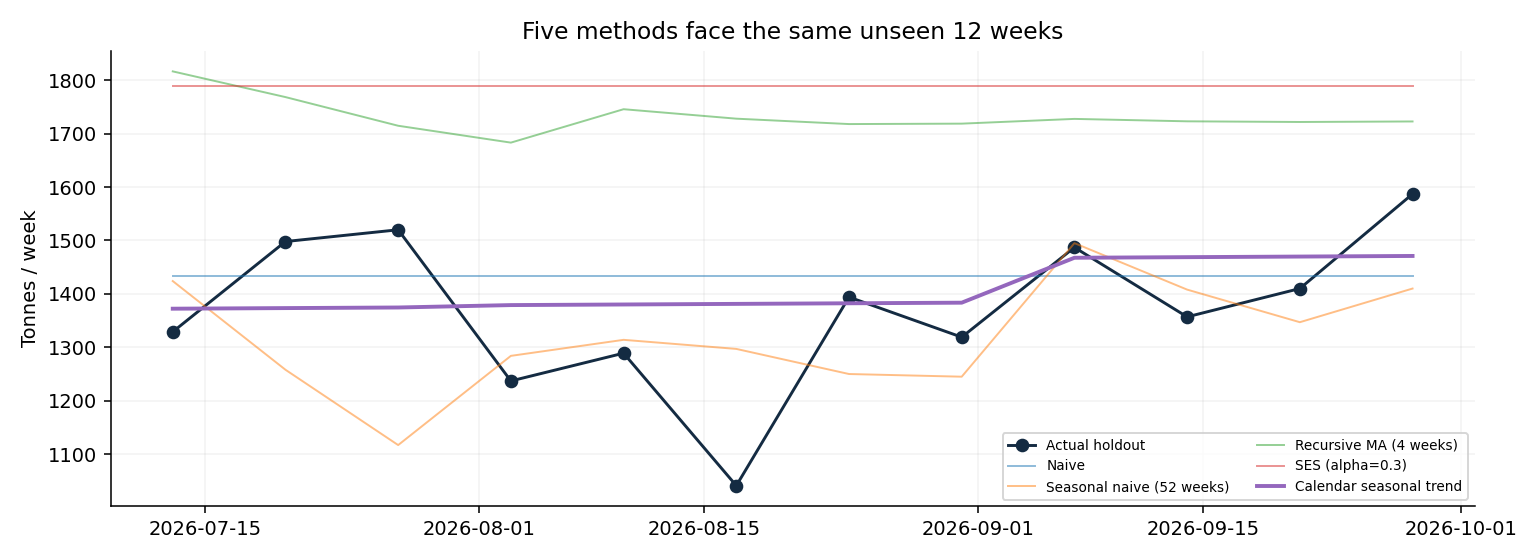

In [4]:
def metric(a,f):
    e=np.asarray(a,dtype=float)-np.asarray(f,dtype=float)
    mad=np.mean(np.abs(e))
    return {'MAD':float(mad),'MAPE_pct':float(np.mean(np.abs(e)/a)*100),'RMSE':float(np.sqrt(np.mean(e**2))),'WAPE_pct':float(np.sum(np.abs(e))/np.sum(a)*100),'Bias':float(np.mean(e)),'RSFE':float(np.sum(e)),'Tracking_Signal':float(np.sum(e)/mad) if mad else 0.}

def seasonal_design(dates,start):
    d=pd.DatetimeIndex(dates)
    time=(d-pd.Timestamp(start)).days.to_numpy()/7
    return np.column_stack([np.ones(len(d)),time]+[(d.month==m).astype(int) for m in range(2,13)])

def forecasts(history,dates,next_dates):
    v=np.asarray(history,dtype=float); h=len(next_dates)
    naive=np.repeat(v[-1],h)
    seasonal=np.array([v[len(v)-52+j] for j in range(h)])
    recursive=list(v)
    moving=[]
    for _ in range(h):
        f=float(np.mean(recursive[-4:])); moving.append(f); recursive.append(f)
    level=v[0]
    for value in v[1:]: level=.3*value+.7*level
    # Fixed specification before holdout evaluation: intercept, linear time, month dummies.
    xd=seasonal_design(dates,df.Week_Start_Date.iloc[0])
    coef=np.linalg.lstsq(xd,v,rcond=None)[0]
    pred=seasonal_design(next_dates,df.Week_Start_Date.iloc[0])@coef
    return {'Naive':naive,'Seasonal naive (52 weeks)':seasonal,'Recursive MA (4 weeks)':np.array(moving),'SES (alpha=0.3)':np.repeat(level,h),'Calendar seasonal trend':np.maximum(0,pred)}

preds=forecasts(tr,train_df.Week_Start_Date,test_df.Week_Start_Date)
comparison=pd.DataFrame([{'Model':name,**metric(actual,v)} for name,v in preds.items()])
comparison=comparison.sort_values('WAPE_pct').reset_index(drop=True)
best=str(comparison.iloc[0].Model); best_metrics=metric(actual,preds[best])
comments={'Naive':'Transparent level baseline; cannot anticipate seasonal transitions.','Seasonal naive (52 weeks)':'Repeats the prior year, including its unusual weeks; no trend adjustment.','Recursive MA (4 weeks)':'Recent level benchmark; never updates with held-out actuals.','SES (alpha=0.3)':'Fixed alpha; level only; no seasonal structure.','Calendar seasonal trend':'Date-only seasonality and trend; cannot anticipate unplanned availability shocks.'}
comparison['Managerial_comment']=comparison.Model.map(comments)
comparison.to_csv(ROOT/(PREFIX+'_Model_Comparison.csv'),index=False)
holdout=test_df[['Week_Start_Date','Actual_Demand_Tonnes','Promo_Flag','Event_Flag','Monsoon_Flag','Stockout_Flag','Exceptional_Event']].copy()
for name,v in preds.items(): holdout[name]=v
holdout['Error']=actual-preds[best]; holdout['Absolute_Error']=np.abs(holdout.Error)
holdout.to_csv(ROOT/(PREFIX+'_Holdout_Results.csv'),index=False)
print(comparison.round(3).to_string(index=False)); print('Selected method:',best)
print('Selection uses WAPE, then reviews bias and behaviour. No retuning or data regeneration after holdout. Selection itself may be optimistic on this single holdout; a second holdout or rolling-origin validation would strengthen evidence.')
fig,ax=plt.subplots(figsize=(11,4))
ax.plot(test_df.Week_Start_Date,actual,'o-',color='#142b42',label='Actual holdout')
for name,v in preds.items(): ax.plot(test_df.Week_Start_Date,v,label=name,lw=2 if name==best else 1,alpha=1 if name==best else .5)
ax.set(title='Five methods face the same unseen 12 weeks',ylabel='Tonnes / week'); ax.legend(fontsize=7,ncol=2);fig.tight_layout();fig.savefig(ROOT/'holdout.png');plt.close(fig)



## 5. Largest misses and independent arithmetic checks

In [5]:
def diagnose(row):
    if row.Stockout_Flag: return 'Availability-constrained observed sales; date-only model cannot anticipate unannounced dispatch interruption.'
    if row.Promo_Flag: return 'Dealer promotion associated with uplift; seasonal model does not explicitly model planned discounts.'
    if row.Exceptional_Event and not pd.isna(row.Exceptional_Event): return 'Exceptional incident; association is a synthetic design feature, not independently verified company evidence.'
    if row.Monsoon_Flag: return 'Monsoon-period variability, construction-activity variation and noise; a calendar effect does not explain every week.'
    return 'Model approximation plus construction-activity variation/noise; exact attribution cannot be identified from forecast error alone.'
misses=holdout.nlargest(5,'Absolute_Error').copy()
misses['Diagnosis']=misses.apply(diagnose,axis=1)
misses.to_csv(ROOT/(PREFIX+'_Five_Largest_Misses.csv'),index=False)
print(misses[['Week_Start_Date','Actual_Demand_Tonnes',best,'Error','Diagnosis']].round(1).to_string(index=False))
errors=[float(a-f) for a,f in zip(actual,preds[best])]
abs_errors=[abs(e) for e in errors]
manual={'MAD':sum(abs_errors)/12,'WAPE_pct':100*sum(abs_errors)/sum(float(a) for a in actual),'RMSE':math.sqrt(sum(e*e for e in errors)/12),'Bias':sum(errors)/12,'RSFE':sum(errors),'MAPE_pct':100*sum(abs(e)/float(a) for e,a in zip(errors,actual))/12,'Tracking_Signal':sum(errors)/(sum(abs_errors)/12)}
for k,v in manual.items(): assert math.isclose(v,best_metrics[k],rel_tol=1e-10,abs_tol=1e-8)
print('Separate scalar-loop recomputation agrees for all seven metrics. This is a code cross-check; student Excel/hand verification remains an explicit learning task.')



Week_Start_Date  Actual_Demand_Tonnes  Calendar seasonal trend  Error                                                                                                             Diagnosis
     2026-08-17                  1041                   1381.3 -340.3         Availability-constrained observed sales; date-only model cannot anticipate unannounced dispatch interruption.
     2026-07-27                  1520                   1374.5  145.5                  Dealer promotion associated with uplift; seasonal model does not explicitly model planned discounts.
     2026-08-03                  1237                   1379.0 -142.0 Monsoon-period variability, construction-activity variation and noise; a calendar effect does not explain every week.
     2026-07-20                  1498                   1373.4  124.6 Monsoon-period variability, construction-activity variation and noise; a calendar effect does not explain every week.
     2026-09-28                  1587                   1471

## 6. Multiple regression (training observations only)

In [6]:
features=['Price_PKR_per_Tonne','Promo_Flag','Event_Flag','Construction_Activity_Index','Monsoon_Flag','Stockout_Flag','Time_Weeks']
reg_train=train_df.copy(); reg_train['Time_Weeks']=np.arange(len(train_df))
X=np.column_stack([np.ones(len(reg_train)),reg_train[features].to_numpy(dtype=float)])
# QR/SVD solve for OLS; no unavailable external regression package is needed.
beta=np.linalg.lstsq(X,tr,rcond=None)[0]
residual=tr-X@beta; n,k=X.shape; dof=n-k
cov=(residual@residual/dof)*np.linalg.inv(X.T@X)
se=np.sqrt(np.diag(cov)); tstat=beta/se; p=2*stats.t.sf(np.abs(tstat),dof)
r2=1-float(residual@residual)/float(np.sum((tr-tr.mean())**2))
adjr2=1-(1-r2)*(n-1)/dof
reg=pd.DataFrame({'Variable':['Intercept']+features,'Coefficient':beta,'Standard_Error':se,'t_stat':tstat,'p_value':p,'CI95_low':beta-stats.t.ppf(.975,dof)*se,'CI95_high':beta+stats.t.ppf(.975,dof)*se})
reg.to_csv(ROOT/(PREFIX+'_Regression.csv'),index=False)
condition=float(np.linalg.cond(X/np.linalg.norm(X,axis=0)))
dw=float(np.sum(np.diff(residual)**2)/np.sum(residual**2))
print(reg.round(5).to_string(index=False));print(f'R-squared={r2:.4f}; adjusted R-squared={adjr2:.4f}; Durbin-Watson={dw:.3f}; scaled condition number={condition:.1f}')
print('Each coefficient is associated with tonnes/week per unit, holding included variables constant. Price: per PKR/tonne; promo/event/monsoon/stockout: change from 0 to 1; index: per point; time: per week. Intercept at zero price and zero index lies outside the data and is not a useful baseline.')
print('OLS p-values assume independent, homoskedastic errors; not causal proof. Synthetic design embeds relationships. Omitted variables include credit terms, dealer inventory, project timing and competitor pricing. Promotions can shift dealer purchases rather than final cement consumption. Time and price can be correlated. These are learning results, not evidence of real Lucky Cement elasticities.')



                   Variable  Coefficient  Standard_Error   t_stat  p_value   CI95_low  CI95_high
                  Intercept   1143.60848       867.31724  1.31856  0.18953 -571.56408 2858.78104
        Price_PKR_per_Tonne     -0.04686         0.04277 -1.09565  0.27517   -0.13143    0.03772
                 Promo_Flag    371.76881        24.52031 15.16167  0.00000  323.27840  420.25922
                 Event_Flag    224.60721        24.69093  9.09675  0.00000  175.77939  273.43502
Construction_Activity_Index     13.42572         2.12909  6.30583  0.00000    9.21530   17.63613
               Monsoon_Flag   -324.46270        34.12203 -9.50889  0.00000 -391.94109 -256.98430
              Stockout_Flag   -584.44775        63.81732 -9.15814  0.00000 -710.65038 -458.24511
                 Time_Weeks      1.64748         0.95727  1.72103  0.08752   -0.24557    3.54054
R-squared=0.8567; adjusted R-squared=0.8493; Durbin-Watson=1.832; scaled condition number=264.8
Each coefficient is associated 

## 7. Refit the unchanged selected specification and forecast future weeks

In [7]:
future_dates=pd.date_range('2026-10-05',periods=12,freq='W-MON')
future_values=forecasts(y,df.Week_Start_Date,future_dates)[best]
future=pd.DataFrame({'Week_Start_Date':future_dates,'Forecast_Tonnes':future_values})
mad=best_metrics['MAD']
# Illustrative risk band; not a calibrated probability interval.
future['Indicative_Low']=np.maximum(0,future_values-2*mad)
future['Indicative_High']=future_values+2*mad
future['Commit_Tonnes']=.8*future_values
future['Flexible_Base_Tonnes']=.2*future_values
future.to_csv(ROOT/(PREFIX+'_Future_Forecast.csv'),index=False)
total=float(future_values.sum());commit=.8*total;flex=.2*total
CAPACITY=2400.; COST=17000.; MARGIN=4500.; BUFFER_WEEKS=2
buffer=BUFFER_WEEKS*mad
print(f'Future period: {future_dates.min().date()} to {future_dates.max().date()}')
print(f'Forecast {total:,.0f} tonnes; commit {commit:,.0f}; flexible base {flex:,.0f}; separate illustrative buffer {buffer:,.0f} tonnes.')
print('Forecast is expected volume. Commitment is a contingent operating plan, not a sales target. Commit means schedule/reserve 80% across the horizon, not manufacture the whole volume immediately. Opening stock is assumed zero outside the buffer.')



Future period: 2026-10-05 to 2026-12-21
Forecast 22,109 tonnes; commit 17,687; flexible base 4,422; separate illustrative buffer 212 tonnes.
Forecast is expected volume. Commitment is a contingent operating plan, not a sales target. Commit means schedule/reserve 80% across the horizon, not manufacture the whole volume immediately. Opening stock is assumed zero outside the buffer.


## 8. Stress test the operating plan with explicit financial assumptions

                            Scenario  Demand_Tonnes  Fixed_Plan_Excess_Tonnes  Fixed_Plan_Shortage_Tonnes  Responsive_End_Inventory_Tonnes  Responsive_Unserved_Tonnes  Weekly_Capacity_Gap_Tonnes  Excess_Stock_Cost_PKR  Lost_Contribution_PKR
                                Base        22109.0                       0.0                         0.0                            211.7                         0.0                         0.0                    0.0                    0.0
                       Downside -20%        17687.2                    4421.8                         0.0                            211.7                         0.0                         0.0             75170632.2                    0.0
                         Upside +20%        26530.8                       0.0                      4421.8                            211.7                         0.0                         0.0                    0.0                    0.0
     Dealer event +30% first 2 weeks

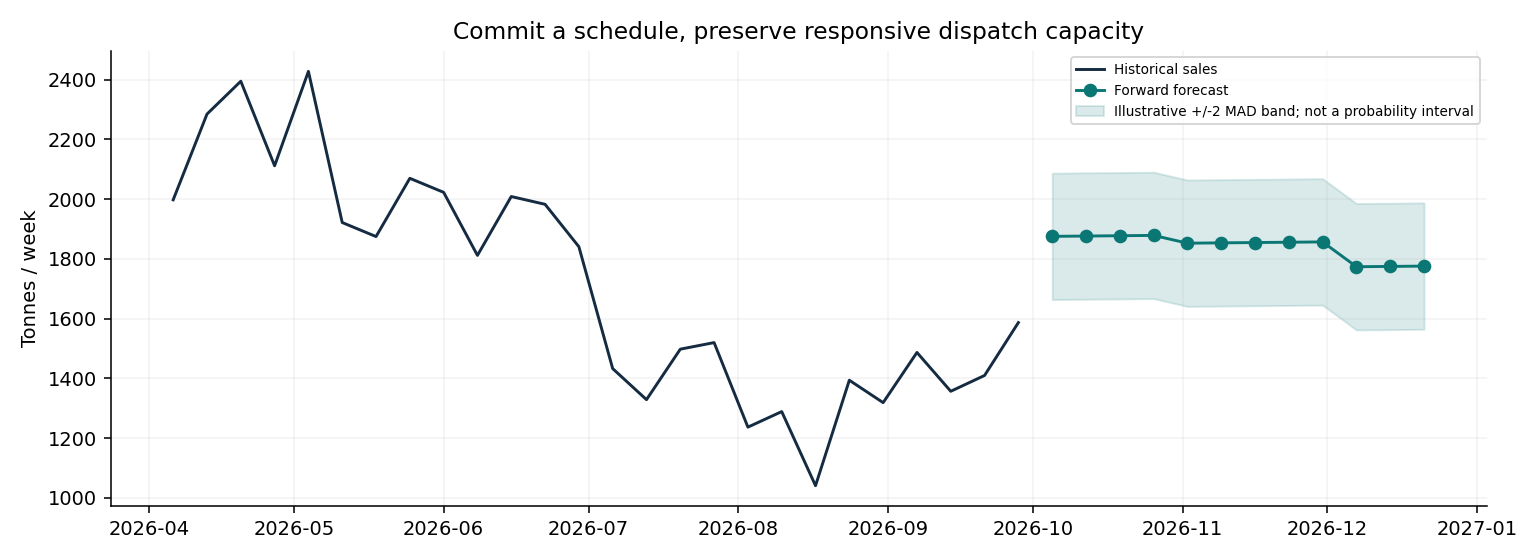

In [8]:
scenarios=[]
for name,demand,capacity in [('Base',future_values,np.repeat(CAPACITY,12)),('Downside -20%',future_values*.8,np.repeat(CAPACITY,12)),('Upside +20%',future_values*1.2,np.repeat(CAPACITY,12)),('Dealer event +30% first 2 weeks',future_values*np.r_[1.3,1.3,np.ones(10)],np.repeat(CAPACITY,12)),('Dispatch capacity -40% first 2 weeks',future_values,np.r_[CAPACITY*.6,CAPACITY*.6,np.repeat(CAPACITY,10)])]:
    # Fixed plan is the base forecast. Responsive plan can adjust the flexible portion weekly,
    # never below its existing 80% commitment, and never above dispatch capacity.
    fixed_supply=np.minimum(future_values,capacity)
    fixed_excess=float(np.maximum(fixed_supply-demand,0).sum())
    fixed_short=float(np.maximum(demand-fixed_supply,0).sum())
    responsive_supply=np.minimum(capacity,np.maximum(.8*future_values,demand))
    inv=buffer; lost=0.; additions=0.
    for dem,supply in zip(demand,responsive_supply):
        available=inv+supply; unmet=max(dem-available,0.);lost+=unmet;inv=max(available-dem,0.)
    capgap=float(np.maximum(demand-capacity,0).sum())
    scenarios.append({'Scenario':name,'Demand_Tonnes':float(demand.sum()),'Fixed_Plan_Excess_Tonnes':fixed_excess,'Fixed_Plan_Shortage_Tonnes':fixed_short,'Responsive_End_Inventory_Tonnes':float(inv),'Responsive_Unserved_Tonnes':float(lost),'Weekly_Capacity_Gap_Tonnes':capgap,'Excess_Stock_Cost_PKR':fixed_excess*COST,'Lost_Contribution_PKR':lost*MARGIN})
scenario=pd.DataFrame(scenarios);scenario.to_csv(ROOT/(PREFIX+'_Stress_Tests.csv'),index=False)
print(scenario.round(1).to_string(index=False))
print(f'Assumptions: territory capacity {CAPACITY:,.0f} t/week; variable stock cost PKR {COST:,.0f}/t; lost contribution PKR {MARGIN:,.0f}/t; weekly flexible supply can respond within one week. Buffer={BUFFER_WEEKS}x holdout MAD, not an optimised service-level safety stock. Storage cost/taxes/finance cost excluded.')
TRIGGER='Reforecast weekly; escalate if either of the first two actual weeks differs from forecast by more than 10%, rolling Tracking Signal exceeds +/-4, or a dispatch interruption is announced. The +/-4 band is an assumed monitoring rule, not a proven service guarantee.'
recommendation=f'Use the forecast provisionally: the holdout Tracking Signal already breaches the assumed +/-4 band, requiring immediate stockout/bias review before operational release. Schedule {commit:,.0f} tonnes (80%) across 12 weeks; retain {flex:,.0f} tonnes (20%) of base-volume flexibility and reserve access to 20% upside capacity. Hold an illustrative {buffer:,.0f}-tonne buffer separately, costing PKR {buffer*COST/1e6:.2f}m under the assumed unit cost. Do not prebuild all 12 weeks of cement. {TRIGGER}'
print(recommendation)
results={'label':LABEL,'decision':DECISION,'seed':SEED,'dataset_sha256':DATA_HASH,'company_net_revenue_pkr':REVENUE,'territory_sales_proxy_pkr':territory_sales,'best_model':best,'metrics':best_metrics,'description':descriptive(y),'train_description':descriptive(tr),'r2':r2,'adjusted_r2':adjr2,'condition_number':condition,'durbin_watson':dw,'total_forecast':total,'commit':commit,'flexible':flex,'buffer':buffer,'capacity':CAPACITY,'stock_cost':COST,'lost_margin':MARGIN,'recommendation':recommendation,'diagnosis':DIAGNOSIS,'trigger':TRIGGER}
(ROOT/(PREFIX+'_Results.json')).write_text(json.dumps(results,indent=2),encoding='utf-8')
fig,ax=plt.subplots(figsize=(11,4))
ax.plot(df.Week_Start_Date.iloc[-26:],y[-26:],label='Historical sales',color='#142b42')
ax.plot(future_dates,future_values,'o-',label='Forward forecast',color='#0b7775')
ax.fill_between(future_dates,future.Indicative_Low,future.Indicative_High,alpha=.15,color='#0b7775',label='Illustrative +/-2 MAD band; not a probability interval')
ax.set(title='Commit a schedule, preserve responsive dispatch capacity',ylabel='Tonnes / week');ax.legend(fontsize=7);fig.tight_layout();fig.savefig(ROOT/'future.png');plt.close(fig)
